# **Thu thập dữ liệu**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm
from scipy.stats import ks_2samp, chi2_contingency
import gdown
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
drive_files = {
    'inventory': '1vAMltQY1HzyfYbSaqHmiX7vG3x-0nzgg',
    'products': '1ChaIE-mxZusnsUN3uPQLzrgO8iWFFB_o',
    'returns': '1MfqBi7Kvo2GEKG8PlERQPIB2NMqIsW5_',
    'payments': '1uauLXN2gHWTuN1Hznp9Bi98Z58PNyqZX',
    'web_traffic': '1YwWikoZJyQYEMrcc--CNweJF_wZ-9HF5',
    'orders': '1qgJAYEH1M5w5syZCHsCof4v5yYHDglZ8',
    'order_items': '189g8Scbtk_bwKeLgu1V93UMw9uMWYcC_',
    'geography': '1AoHEINjy0G6evkcn6G0ZQlSrRi-H8sCw',
    'shipments': '1Lhsc127N9EBu0rQTWrBMPjo9RJ0bxXQq',
    'reviews': '11uSO9FqGruJxtwiAtbOrn0bYqembKjky'
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

inventory = dfs['inventory']
orders = dfs['orders']
order_items = dfs['order_items']
payments = dfs['payments']
shipments = dfs['shipments']
returns = dfs['returns']
reviews = dfs['reviews']
geography = dfs['geography']
web_traffic = dfs['web_traffic']
products = dfs['products']

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: inventory
Đã tải xong: products
Đã tải xong: returns
Đã tải xong: payments
Đã tải xong: web_traffic
Đã tải xong: orders
Đã tải xong: order_items
Đã tải xong: geography
Đã tải xong: shipments
Đã tải xong: reviews


In [4]:
# Chuyển đổi định dạng ngày tháng
orders['order_date'] = pd.to_datetime(orders['order_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

# **PHẦN 1: PHÂN TÍCH HIỆU QUẢ KINH DOANH**

# 1.1. Doanh thu theo ABC Analysis (Phân loại sản phẩm)

In [5]:
# Xác định 20% sản phẩm nào tạo ra 80% doanh thu.
# Merge dữ liệu để có bảng doanh thu chi tiết
sales_data = order_items.merge(products, on='product_id')
sales_data['total_revenue'] = sales_data['quantity'] * sales_data['price']

# 1. ABC Analysis
abc_analysis = sales_data.groupby('product_name')['total_revenue'].sum().reset_index()
abc_analysis = abc_analysis.sort_values(by='total_revenue', ascending=False)

# Tính tỷ lệ phần trăm tích lũy
abc_analysis['revenue_share'] = abc_analysis['total_revenue'] / abc_analysis['total_revenue'].sum()
abc_analysis['cumulative_share'] = abc_analysis['revenue_share'].cumsum()

# Phân loại A, B, C
def categorize_abc(row):
    if row['cumulative_share'] <= 0.80: return 'A (Key Products)'
    elif row['cumulative_share'] <= 0.95: return 'B (Medium)'
    else: return 'C (Slow Moving)'

abc_analysis['category_abc'] = abc_analysis.apply(categorize_abc, axis=1)
print(abc_analysis['category_abc'].value_counts())

category_abc
C (Slow Moving)     827
B (Medium)          345
A (Key Products)    268
Name: count, dtype: int64


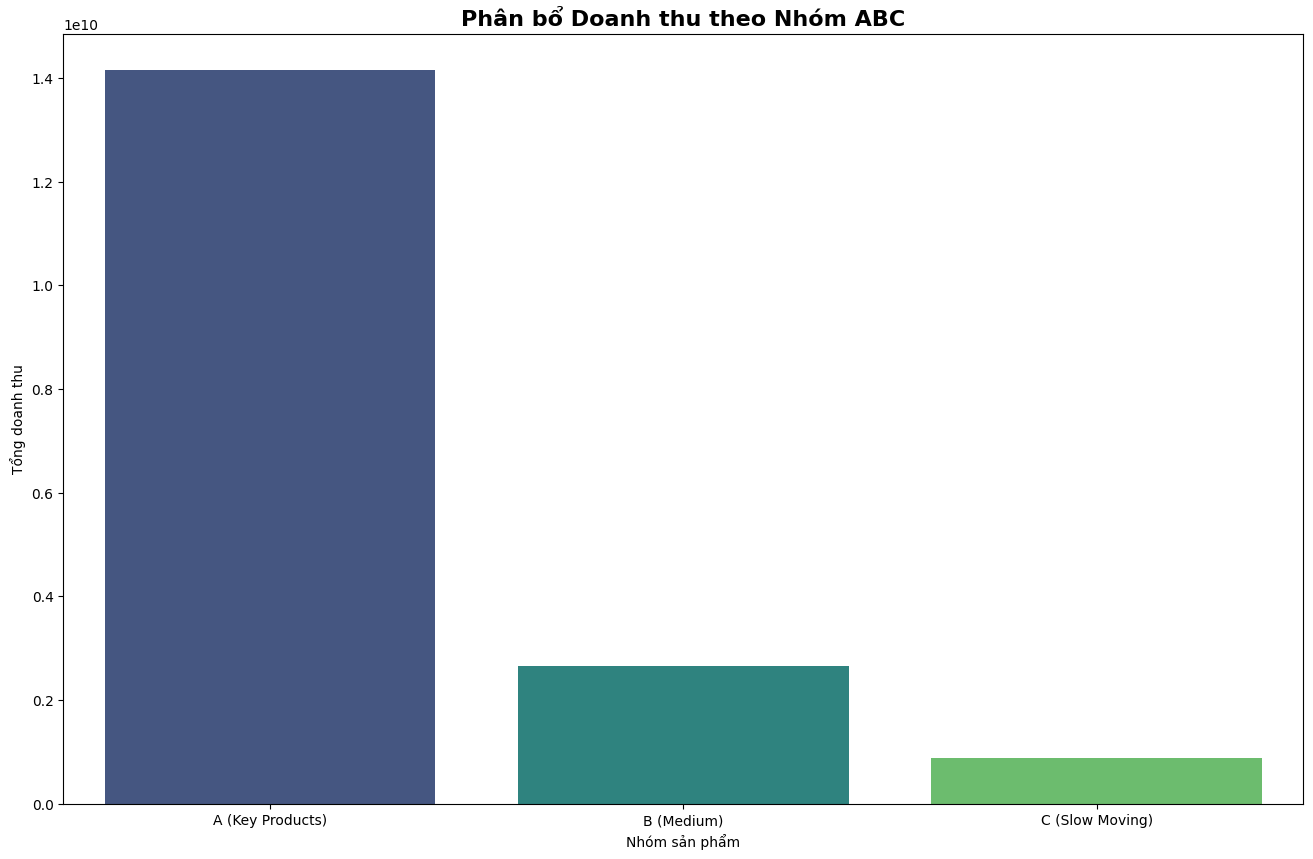

In [6]:
# Phân tích ABC (sales performance)
fig = plt.figure(figsize=(16, 10))
sns.barplot(x='category_abc', y='total_revenue', data=abc_analysis,
            estimator='sum', palette='viridis', hue='category_abc', errorbar=None, legend=False)
plt.title('Phân bổ Doanh thu theo Nhóm ABC', fontsize=16, fontweight='bold')
plt.xlabel('Nhóm sản phẩm')
plt.ylabel('Tổng doanh thu')
plt.show()

# 1.2.  Phân tích Biên Lợi nhuận Thực tế (True Profitability)

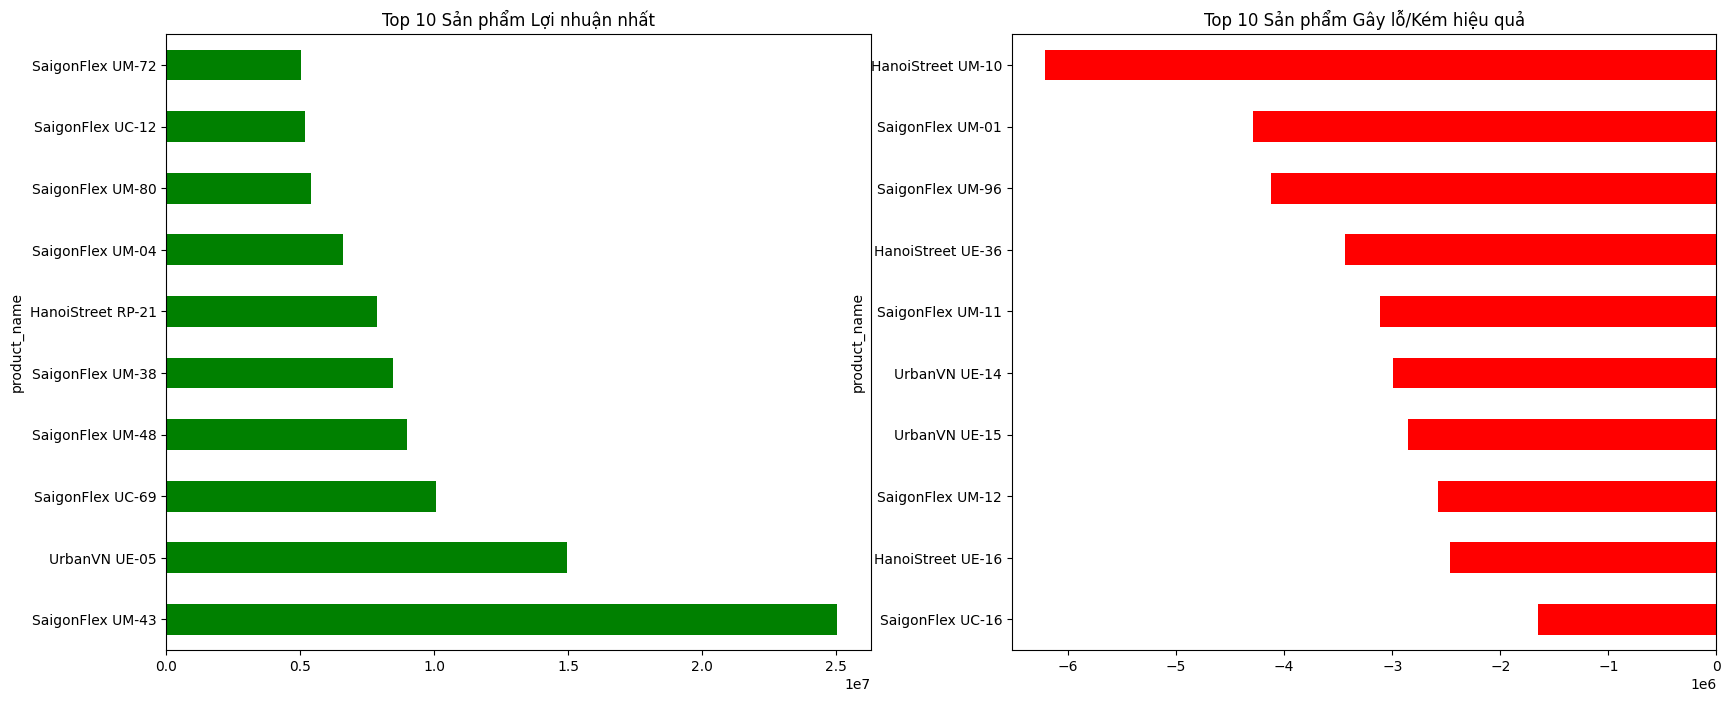

In [7]:
# Tính toán lợi nhuận sau khi đã trừ đi chi phí Khuyến mãi, chi phí Vận chuyển và đặc biệt là tổn thất do Hoàn hàng.
# Tính doanh thu gộp, tiền khuyến mãi và tiền hoàn trả trên từng sản phẩm
profit_data = order_items.merge(products[['product_id', 'product_name', 'cogs']], on='product_id')
profit_data = profit_data.merge(returns[['order_id', 'return_id']], on='order_id', how='left')

profit_data['is_returned'] = profit_data['return_id'].notnull()

# Tính Profit thực tế: Doanh thu - COGS - (Nếu hoàn hàng thì mất luôn COGS và không có doanh thu)
def calculate_net_profit(row):
    if row['is_returned']:
        return -(row['cogs']) # Mất chi phí hàng hóa và vận chuyển khi khách hoàn
    else:
        return row['unit_price'] - row['cogs'] # Sử dụng unit_price từ order_items

profit_data['net_profit'] = profit_data.apply(calculate_net_profit, axis=1)

# Trực quan hóa Top 10 sản phẩm mang lại lợi nhuận thực tế cao nhất vs thấp nhất
top_profit = profit_data.groupby('product_name')['net_profit'].sum().sort_values(ascending=False).head(10)
bottom_profit = profit_data.groupby('product_name')['net_profit'].sum().sort_values(ascending=False).tail(10)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
top_profit.plot(kind='barh', ax=ax[0], color='green').set_title('Top 10 Sản phẩm Lợi nhuận nhất')
bottom_profit.plot(kind='barh', ax=ax[1], color='red').set_title('Top 10 Sản phẩm Gây lỗ/Kém hiệu quả')
plt.show()

In [8]:
# Tổng hợp lợi nhuận ròng theo sản phẩm
product_profit_summary = profit_data.groupby('product_name')['net_profit'].sum().reset_index()
print("Tổng hợp lợi nhuận ròng theo sản phẩm:")
display(product_profit_summary.head())

Tổng hợp lợi nhuận ròng theo sản phẩm:


,product_name,net_profit
0,BambooCraft UC-02,-32528.149581
1,BambooCraft UC-03,332192.067983
2,BambooCraft UC-04,3592.082810
3,BambooCraft UC-05,81314.798125
4,BambooCraft UC-07,-8430.974304


# 1.3. Phân khúc khách hàng RFM (Recency, Frequency, Monetary)

In [9]:
# Xác định nhóm khách hàng nào trung thành nhất.
# Thêm cột năm
orders['year'] = orders['order_date'].dt.year

# Merge dữ liệu
df = orders.merge(payments, on='order_id')

# Hàm tính RFM theo từng nhóm (customer_id, year)
def compute_rfm(group):
    year = group['year'].iloc[0]
    snapshot_date = pd.Timestamp(f"{year}-12-31") + pd.Timedelta(days=1)

    return pd.Series({
        'Recency': (snapshot_date - group['order_date'].max()).days,
        'Frequency': group['order_id'].nunique(),
        'Monetary': group['payment_value'].sum()
    })

# Tính RFM theo từng năm
rfm = df.groupby(['customer_id', 'year']).apply(compute_rfm).reset_index()

# Chia điểm theo từng năm (quan trọng!)
rfm['R_score'] = rfm.groupby('year')['Recency'] \
    .transform(lambda x: pd.qcut(x, 5, labels=[5,4,3,2,1]))

rfm['F_score'] = rfm.groupby('year')['Frequency'] \
    .transform(lambda x: pd.qcut(x.rank(method='first'), 5, labels=[1,2,3,4,5]))

rfm['M_score'] = rfm.groupby('year')['Monetary'] \
    .transform(lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5]))

# Ghép segment
rfm['RFM_Segment'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

print(rfm.head())

   customer_id  year  Recency  Frequency  Monetary R_score F_score M_score  \
0            1  2012    160.0        1.0  12627.39       1       1       2   
1            1  2014    215.0        1.0   1478.78       2       1       1   
2            1  2015    154.0        1.0  44708.32       3       1       4   
3            1  2017    253.0        1.0  37213.40       1       1       3   
4            1  2020    312.0        1.0   4233.33       1       1       1   

  RFM_Segment  
0         112  
1         211  
2         314  
3         113  
4         111  


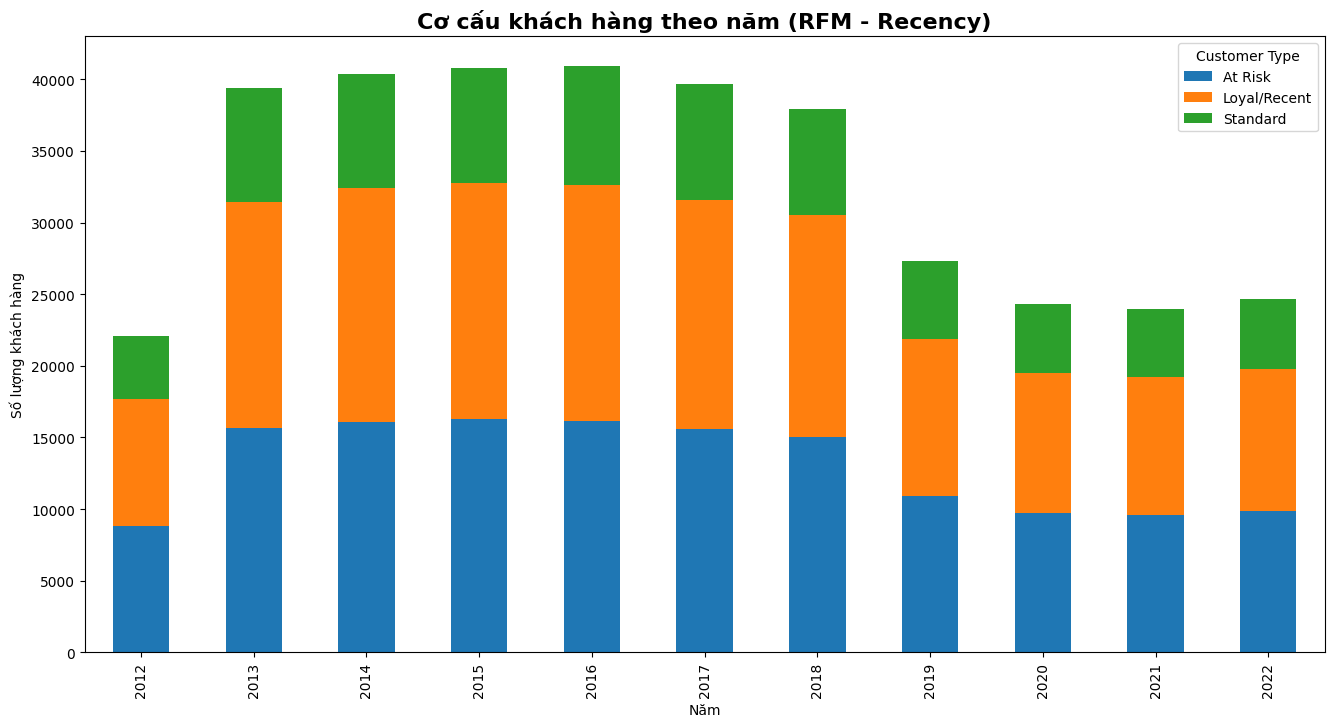

In [10]:
# Phân loại khách hàng
rfm['Customer_Type'] = np.where(
    rfm['R_score'].astype(int) >= 4, 'Loyal/Recent',
    np.where(rfm['R_score'].astype(int) <= 2, 'At Risk', 'Standard')
)

rfm_plot = rfm.groupby(['year', 'Customer_Type']).size().unstack(fill_value=0)

rfm_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 8)
)

plt.title('Cơ cấu khách hàng theo năm (RFM - Recency)', fontsize=16, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Customer Type')
plt.show()

# 1.4. Phân tích Cohort (Giữ chân khách hàng)

In [11]:
# Hiểu xem khách hàng mua hàng tháng 1 có quay lại vào các tháng sau không? Tỷ lệ rơi rụng (Churn) là bao nhiêu?
# Chuẩn bị dữ liệu Cohort
orders['order_month'] = orders['order_date'].dt.to_period('M')
orders['cohort_month'] = orders.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')

cohort_data = orders.groupby(['cohort_month', 'order_month']).agg(n_customers=('customer_id', 'nunique')).reset_index()
cohort_data['period_number'] = (cohort_data.order_month - cohort_data.cohort_month).apply(lambda x: x.n)

# Chuyển thành ma trận
cohort_pivot = cohort_data.pivot_table(index='cohort_month', columns='period_number', values='n_customers')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [12]:
# Trích xuất các tỷ lệ giữ chân quan trọng tại các mốc thời gian cụ thể
# Lưu ý: period_number 0 là tháng gia nhập, 1 là tháng sau, v.v.

retention_summary = pd.DataFrame({
    'Cohort Month': retention_matrix.index.strftime('%Y-%m'),
    'Retention_Month_1': retention_matrix[1].fillna(0).round(4) * 100, # Retention sau 1 tháng
    'Retention_Month_3': retention_matrix[3].fillna(0).round(4) * 100, # Retention sau 3 tháng
    'Retention_Month_6': retention_matrix[6].fillna(0).round(4) * 100, # Retention sau 6 tháng
    'Retention_Month_12': retention_matrix[12].fillna(0).round(4) * 100 # Retention sau 12 tháng
})

# Hiển thị bảng tóm tắt
display(retention_summary.head(15))

# Tính tỷ lệ giữ chân trung bình
print("\nTỷ lệ giữ chân trung bình qua các Cohort:")
print(f"Sau 1 tháng: {retention_summary['Retention_Month_1'].mean():.2f}%")
print(f"Sau 3 tháng: {retention_summary['Retention_Month_3'].mean():.2f}%")
print(f"Sau 6 tháng: {retention_summary['Retention_Month_6'].mean():.2f}%")
print(f"Sau 12 tháng: {retention_summary['Retention_Month_12'].mean():.2f}%")

,Cohort Month,Retention_Month_1,Retention_Month_3,Retention_Month_6,Retention_Month_12
cohort_month,,,,,
2012-07,2012-07,13.78,9.01,8.58,14.56
2012-08,2012-08,11.34,9.17,8.97,15.26
2012-09,2012-09,9.47,11.90,11.54,10.08
2012-10,2012-10,8.22,7.34,15.29,8.41
2012-11,2012-11,12.26,8.84,13.22,8.32
2012-12,2012-12,5.92,9.99,12.41,10.17
2013-01,2013-01,7.66,13.67,11.29,7.78
2013-02,2013-02,9.82,12.04,9.40,6.42
2013-03,2013-03,13.54,10.50,8.49,9.88



Tỷ lệ giữ chân trung bình qua các Cohort:
Sau 1 tháng: 2.96%
Sau 3 tháng: 2.66%
Sau 6 tháng: 2.51%
Sau 12 tháng: 2.65%


# 1.5. Phân tích Giỏ hàng (Market Basket Analysis - MBA)


In [15]:
# Những sản phẩm nào thường được mua cùng nhau?

# Lấy danh sách sản phẩm theo từng đơn hàng
order_bundles = order_items.groupby('order_id')['product_id'].apply(list)

# Đếm các cặp sản phẩm xuất hiện cùng nhau
count = Counter()
for row in order_bundles:
    # Chỉ tạo tổ hợp từ các cặp sản phẩm, không phải tất cả sản phẩm trong giỏ hàng
    # Sắp xếp các cặp để đảm bảo (A, B) và (B, A) được coi là giống nhau
    count.update(tuple(sorted(pair)) for pair in combinations(set(row), 2))

# Lấy top 10 cặp sản phẩm
common_pairs = pd.DataFrame(count.most_common(10), columns=['Pair', 'Frequency'])

# Lấy tên sản phẩm cho từng ID trong cặp
product_names = products.set_index('product_id')['product_name']
common_pairs['Product_A_Name'] = common_pairs['Pair'].apply(lambda x: product_names.get(x[0], 'Unknown Product'))
common_pairs['Product_B_Name'] = common_pairs['Pair'].apply(lambda x: product_names.get(x[1], 'Unknown Product'))
common_pairs['Pair_Names'] = common_pairs.apply(lambda row: f"{row['Product_A_Name']} & {row['Product_B_Name']}", axis=1)

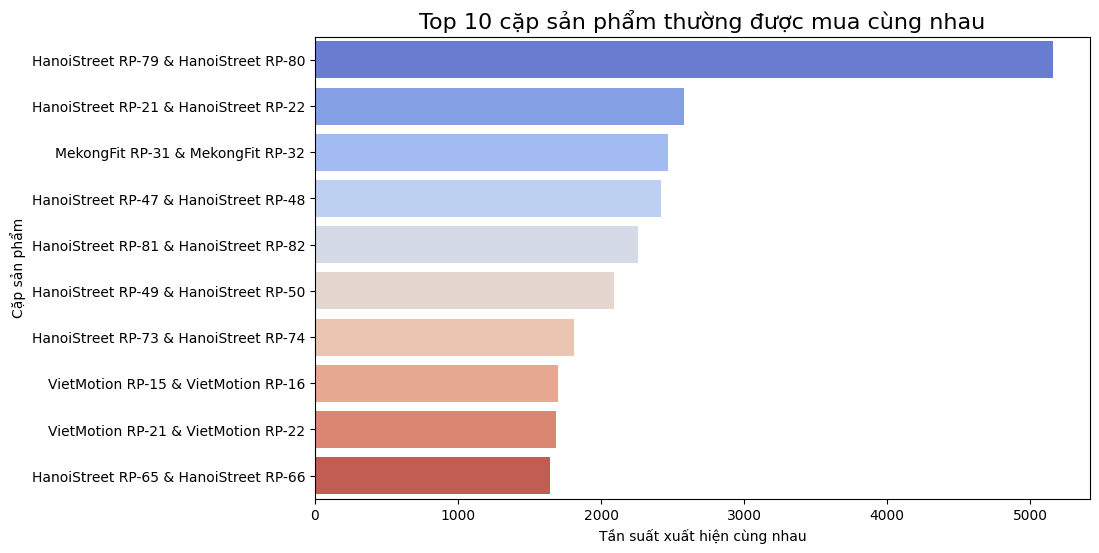

In [16]:
# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.barplot(data=common_pairs, x='Frequency', y='Pair_Names', palette='coolwarm')
plt.title('Top 10 cặp sản phẩm thường được mua cùng nhau', fontsize=16)
plt.xlabel('Tần suất xuất hiện cùng nhau')
plt.ylabel('Cặp sản phẩm')
plt.show()

# 1.6. Phân tích Phễu Chuyển đổi & Lưu lượng (Web Traffic & Conversion)

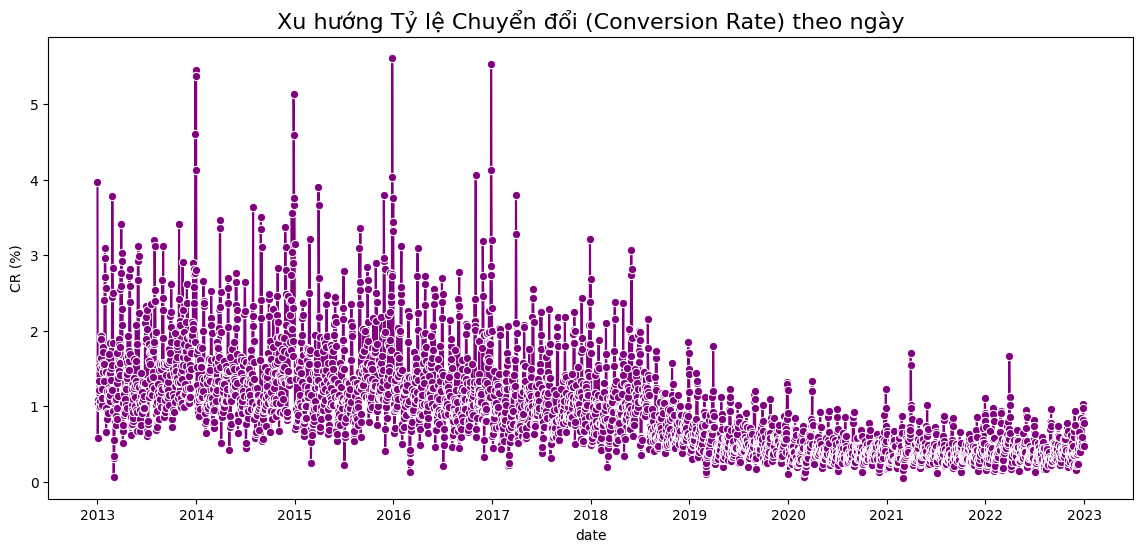

In [17]:
# Hiểu xem khách hàng rời bỏ website ở bước nào và hiệu quả của các kênh truy cập.
# Kết nối với bảng orders
daily_traffic = web_traffic.groupby('date').sum().reset_index()
daily_orders = orders.groupby('order_date').size().reset_index(name='order_count')

# Merge dữ liệu
funnel = daily_traffic.merge(daily_orders, left_on='date', right_on='order_date')

# Tính các tỷ lệ chuyển đổi (Conversion Rate - CR)
funnel['Visit_to_Order_CR'] = (funnel['order_count'] / funnel['unique_visitors']) * 100

# Trực quan hóa xu hướng chuyển đổi
plt.figure(figsize=(14, 6))
sns.lineplot(data=funnel, x='date', y='Visit_to_Order_CR', marker='o', color='purple')
plt.title('Xu hướng Tỷ lệ Chuyển đổi (Conversion Rate) theo ngày', fontsize=16)
plt.ylabel('CR (%)')
plt.show()

# **PHẦN 2: PHÂN TÍCH CHUỖI CUNG ỨNG & VẬN HÀNH**

# 2.1. Phân tích Lead Time (Thời gian giao hàng)

In [18]:
# Mổ xẻ xem khâu nào đang làm chậm tốc độ giao hàng.
# Tính toán các mốc thời gian
shipment_perf = shipments.merge(orders[['order_id', 'order_date']], on='order_id')

# Thời gian xử lý kho (Từ lúc đặt đến lúc xuất kho)
shipment_perf['processing_time'] = (shipment_perf['ship_date'] - shipment_perf['order_date']).dt.days

# Thời gian vận chuyển (Từ lúc xuất kho đến lúc giao tận tay)
shipment_perf['shipping_time'] = (shipment_perf['delivery_date'] - shipment_perf['ship_date']).dt.days

# Tổng thời gian giao hàng
shipment_perf['total_lead_time'] = (shipment_perf['delivery_date'] - shipment_perf['order_date']).dt.days

print(f"Trung bình thời gian giao hàng: {shipment_perf['total_lead_time'].mean():.2f} ngày")

Trung bình thời gian giao hàng: 6.00 ngày


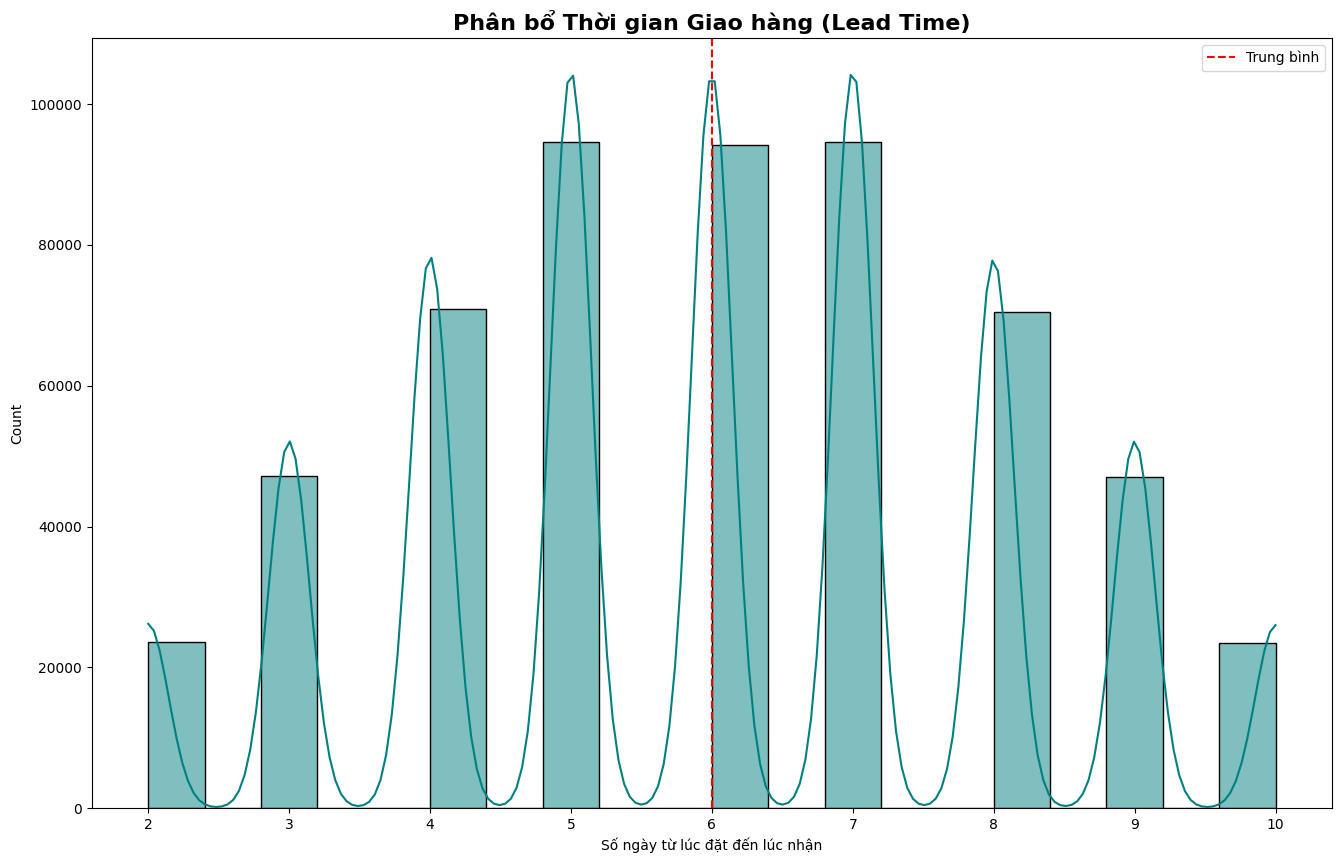

In [19]:
# Hiệu suất giao hàng (lead time)
# Vẽ phân bổ thời gian giao hàng
plt.figure(figsize=(16, 10))
sns.histplot(data=shipment_perf, x='total_lead_time', kde=True, color='teal', bins=20)
plt.axvline(shipment_perf['total_lead_time'].mean(), color='red', linestyle='--', label='Trung bình')
plt.title('Phân bổ Thời gian Giao hàng (Lead Time)', fontsize=16, fontweight='bold')
plt.xlabel('Số ngày từ lúc đặt đến lúc nhận')
plt.legend()
plt.show()

# 2.2. Sức khỏe tồn kho (Inventory Health)


In [20]:
inventory_health = inventory.copy()

# Sử dụng trực tiếp days_of_supply
inventory_health['DOH'] = inventory_health['days_of_supply']

# Phân loại trạng thái tồn kho
inventory_health['status'] = np.where(
    inventory_health['DOH'] < 7, 'Out of Stock Risk',
    np.where(inventory_health['DOH'] > 60, 'Overstock Risk', 'Healthy')
)

print(inventory_health[['product_id', 'stock_on_hand', 'DOH', 'status']].head())

   product_id  stock_on_hand    DOH          status
0           1              3   90.0  Overstock Risk
1           1              3   90.0  Overstock Risk
2           1              3   90.0  Overstock Risk
3           3             35   95.5  Overstock Risk
4           3             36  108.0  Overstock Risk


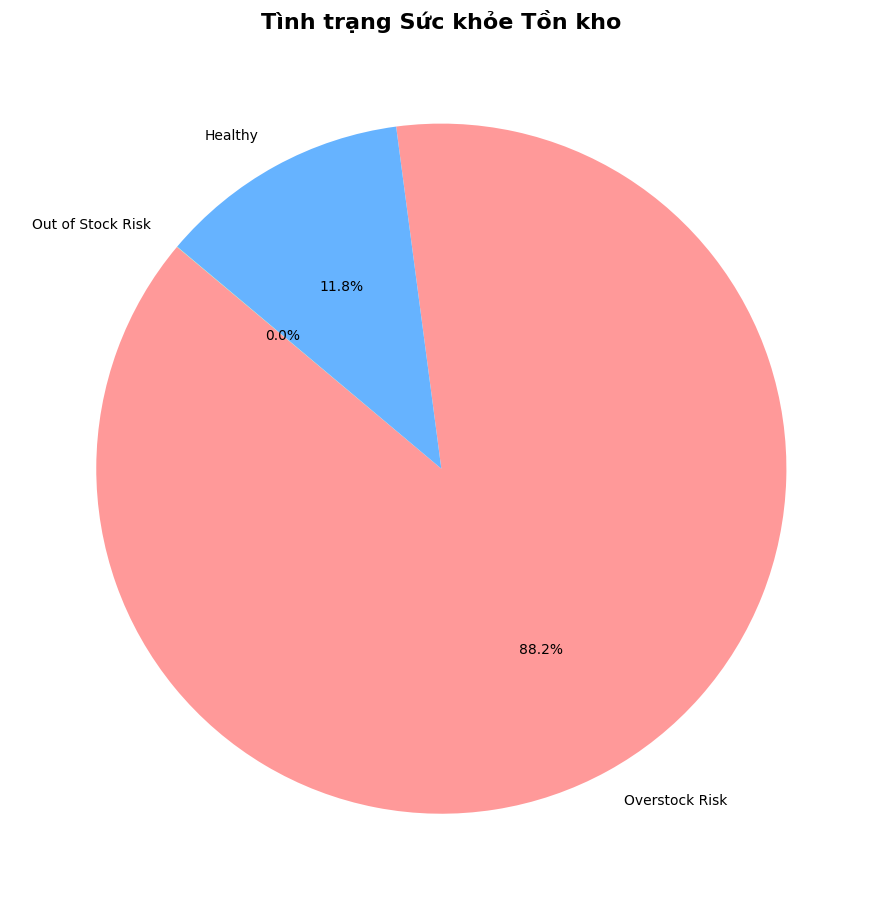

In [21]:
# Sức khỏe tồn kho (inventory health)
status_counts = inventory_health['status'].value_counts()
fig = plt.figure(figsize=(16, 10))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
              startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Tình trạng Sức khỏe Tồn kho', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2.3. Tỷ lệ hàng trả về (Return Rate Analysis)

In [22]:
# Sản phẩm nào hay bị trả lại và tại sao?
# Tính tỷ lệ trả hàng theo sản phẩm
total_qty = order_items.groupby('product_id')['quantity'].sum().reset_index()

# Merge returns và order_items trên cả order_id và product_id để xác định số lượng hàng trả về thực tế
returned_items_with_quantity = returns.merge(order_items, on=['order_id', 'product_id'], how='inner')
return_qty = returned_items_with_quantity.groupby('product_id')['return_quantity'].sum().reset_index()

return_analysis = total_qty.merge(return_qty, on='product_id', how='left')
return_analysis['return_rate'] = (return_analysis['return_quantity'] / return_analysis['quantity']) * 100

# Lấy top sản phẩm bị trả nhiều nhất
top_returns = return_analysis.merge(products, on='product_id').sort_values(by='return_rate', ascending=False)
print(top_returns[['product_name', 'return_rate']].head(10))

           product_name  return_rate
119     LotusWear UR-06    85.714286
1475  PhoenixWear UC-05    75.000000
694     MekongFit RP-09    50.000000
1164   SaigonCore RP-01    50.000000
695     MekongFit RP-10    44.444444
1558   VietMotion UC-04    40.000000
876      VietMode RP-01    37.500000
1108     VietMode RS-91    37.500000
676   MekongStyle UC-14    36.363636
867      VietMode MA-30    33.333333


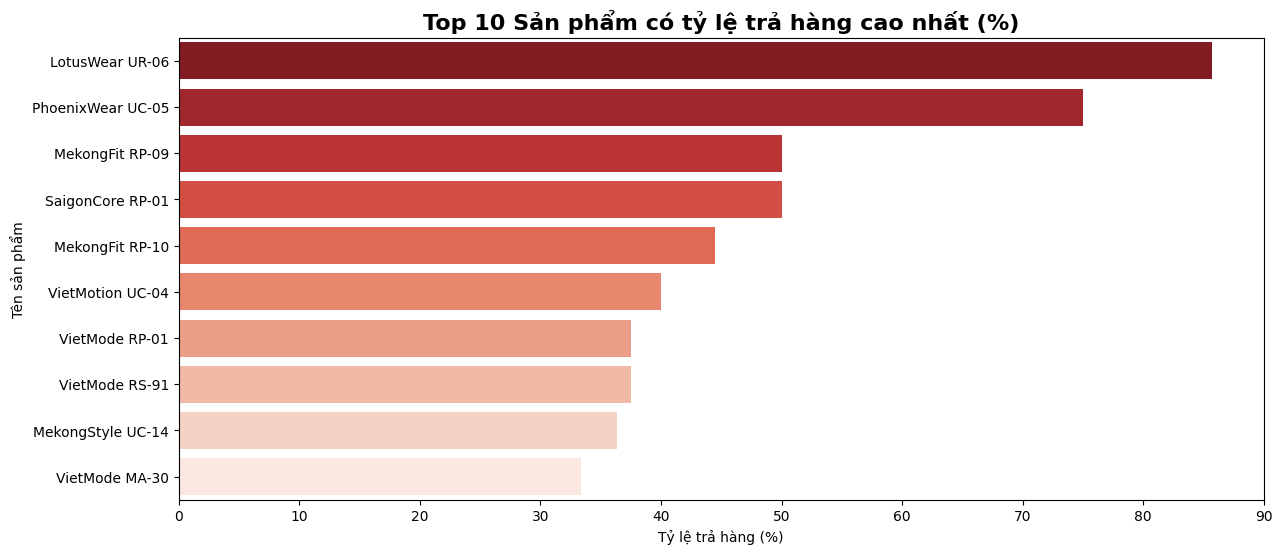

In [23]:
# Tỷ lệ hoàn hàng theo danh mục
plt.figure(figsize=(14, 6))
top_returns_plot = top_returns.head(10)
sns.barplot(x='return_rate', y='product_name', data=top_returns_plot, palette='Reds_r')
plt.title('Top 10 Sản phẩm có tỷ lệ trả hàng cao nhất (%)', fontsize=16, fontweight='bold')
plt.xlabel('Tỷ lệ trả hàng (%)')
plt.ylabel('Tên sản phẩm')
plt.show()

# 2.4. Phân tích Hiệu quả Vận chuyển theo Khu vực Địa lý

In [24]:
# Mục tiêu: Xác định các khu vực có thời gian vận chuyển trung bình cao nhất và đánh giá mối tương quan với điểm phản hồi của khách hàng.
# Kết nối Shipments, Orders, Geography và Reviews
geo_perf = shipments.merge(orders, on='order_id') \
                    .merge(geography, on='zip') \
                    .merge(reviews, on='order_id', how='left')

# Tính thời gian vận chuyển (Từ lúc xuất kho đến lúc giao tận tay)
geo_perf['shipping_time'] = (geo_perf['delivery_date'] - geo_perf['ship_date']).dt.days

# Nhóm theo vùng (Region/State)
region_analysis = geo_perf.groupby('region').agg({
    'shipping_time': 'mean',
    'rating': 'mean',
    'order_id': 'nunique'
}).reset_index()

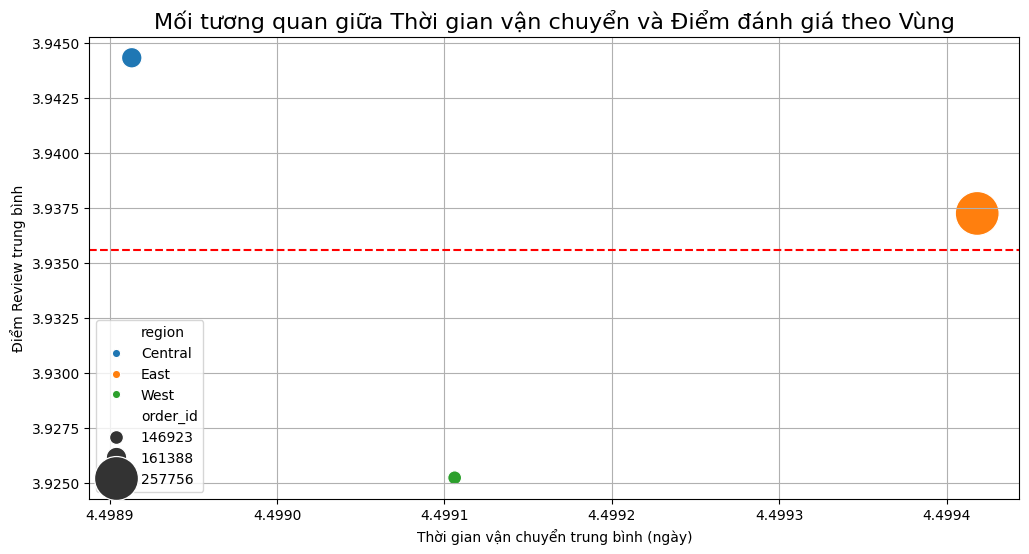

In [25]:
# Trực quan hóa tương quan giữa Thời gian vận chuyển và Review Score
plt.figure(figsize=(12, 6))
sns.scatterplot(data=region_analysis, x='shipping_time', y='rating', size='order_id', hue='region', sizes=(100, 1000))
plt.axhline(region_analysis['rating'].mean(), color='red', linestyle='--')
plt.title('Mối tương quan giữa Thời gian vận chuyển và Điểm đánh giá theo Vùng', fontsize=16)
plt.xlabel('Thời gian vận chuyển trung bình (ngày)')
plt.ylabel('Điểm Review trung bình')
plt.grid(True)
plt.show()

# 2.5. Phân tích Hiệu quả Tồn kho tài chính (Inventory Financial Impact)

In [26]:
# Tính toán giá trị vốn bị đọng trong kho cho các sản phẩm "chết" (không bán được trong 90 ngày).
# Tính ngày bán cuối cùng của từng sản phẩm
last_sale = order_items.merge(orders, on='order_id').groupby('product_id')['order_date'].max().reset_index()
last_sale['days_since_last_sale'] = (orders['order_date'].max() - last_sale['order_date']).dt.days

# Kết hợp với tồn kho và giá
dead_stock = inventory.merge(last_sale, on='product_id', how='left')
dead_stock = dead_stock.merge(products[['product_id', 'price']], on='product_id')

# Định nghĩa hàng tồn kho chết (ví dụ > 90 ngày không có đơn)
dead_stock['stock_value'] = dead_stock['stock_on_hand'] * dead_stock['price']
dead_stock['is_dead'] = dead_stock['days_since_last_sale'] > 90

total_dead_value = dead_stock[dead_stock['is_dead'] == True]['stock_value'].sum()
print(f"TỔNG VỐN BỊ ĐỌNG TRONG HÀNG TỒN CHẾT: ${total_dead_value:,.2f}")

TỔNG VỐN BỊ ĐỌNG TRONG HÀNG TỒN CHẾT: $23,322,143,202.59


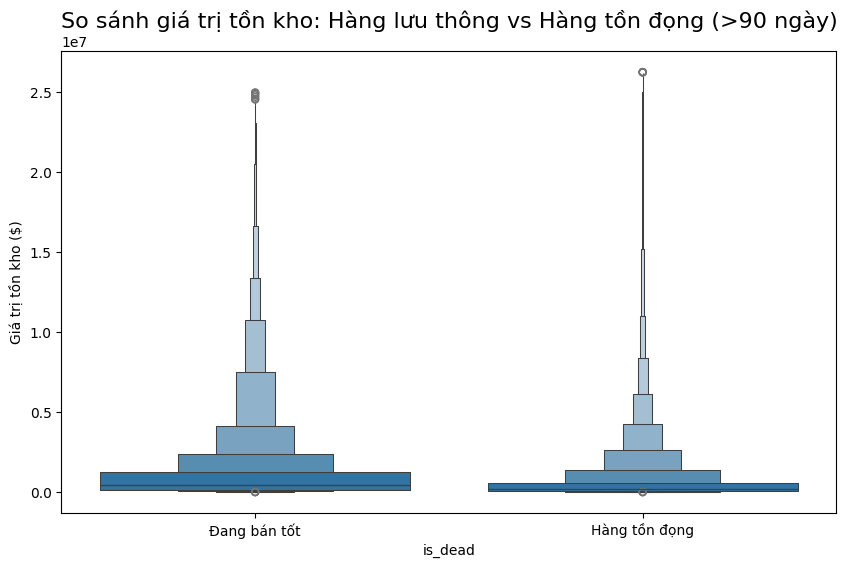

In [27]:
# Trực quan hóa giá trị vốn bị đọng
plt.figure(figsize=(10, 6))
sns.boxenplot(x='is_dead', y='stock_value', data=dead_stock)
plt.title('So sánh giá trị tồn kho: Hàng lưu thông vs Hàng tồn đọng (>90 ngày)', fontsize=16)
plt.xticks([0, 1], ['Đang bán tốt', 'Hàng tồn đọng'])
plt.ylabel('Giá trị tồn kho ($)')
plt.show()

# **Xuất kết quả phân tích**

In [28]:
dataframes_to_export = {
    'abc_analysis': abc_analysis,
    'rfm': rfm,
    'retention_summary': retention_summary,
    'product_profit_summary': product_profit_summary,
    'inventory_health': inventory_health,
    'top_returns': top_returns,
    'region_analysis': region_analysis,
    'dead_stock': dead_stock,
    'common_pairs': common_pairs,
    'funnel': funnel,
    'shipment_perf': shipment_perf
}

for df_name, df_data in dataframes_to_export.items():
    # Ensure 'product_name' columns are strings to avoid potential issues in some tools
    if 'product_name' in df_data.columns:
        df_data['product_name'] = df_data['product_name'].astype(str)

    # Convert PeriodDtype columns to string for compatibility with CSV
    for col in df_data.columns:
        if isinstance(df_data[col].dtype, pd.PeriodDtype):
            df_data[col] = df_data[col].astype(str)

    file_name = f'{df_name}.csv'
    df_data.to_csv(file_name, index=False)
    print(f'Exported {df_name} to {file_name}')

Exported abc_analysis to abc_analysis.csv
Exported rfm to rfm.csv
Exported retention_summary to retention_summary.csv
Exported product_profit_summary to product_profit_summary.csv
Exported inventory_health to inventory_health.csv
Exported top_returns to top_returns.csv
Exported region_analysis to region_analysis.csv
Exported dead_stock to dead_stock.csv
Exported common_pairs to common_pairs.csv
Exported funnel to funnel.csv
Exported shipment_perf to shipment_perf.csv
